In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('cohort_retention.csv')

print(df.shape)
df.head()

(300, 3)


,cohort_month,month_index,active_customers
0,2009-12-01,0,951
1,2009-12-01,1,333
2,2009-12-01,2,317
3,2009-12-01,3,404
4,2009-12-01,4,360


In [3]:
#cohort size
size = df[df['month_index'] == 0].set_index('cohort_month')['active_customers']
df['cohort_size'] = df['cohort_month'].map(size)

print(size.sum())

5824


In [16]:
g = df.groupby('month_index')[['active_customers', 'cohort_size']].sum()
curve = (g['active_customers'] / g['cohort_size'])

print((curve * 100).round(1))

month_index
0     100.0
1      23.3
2      23.6
3      25.0
4      22.8
5      21.9
6      22.2
7      21.8
8      19.9
9      19.4
10     19.7
11     21.8
12     22.7
13     19.7
14     18.2
15     20.3
16     20.2
17     21.5
18     21.1
19     23.2
20     24.1
21     25.6
22     29.0
23     40.6
dtype: float64


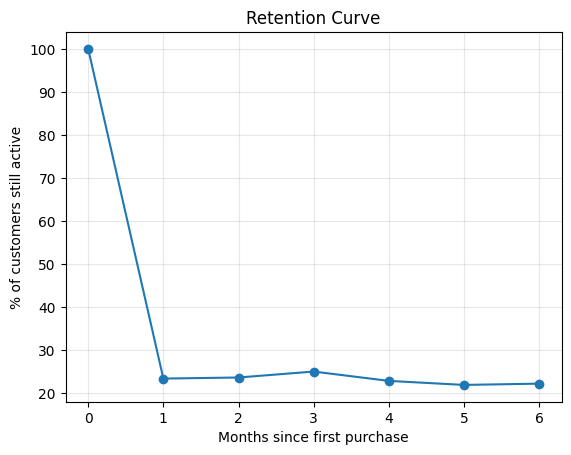

In [15]:
plt.plot(curve.index, curve * 100, marker='o')
plt.title('Retention Curve')
plt.xlabel('Months since first purchase')
plt.ylabel('% of customers still active')
plt.grid(alpha=0.3)
plt.show()